# Blok 1 · Workflow projektu uczenia maszynowego

**Uczenie maszynowe w Pythonie** — Politechnika Gdańska, 2026

Na tych zajęciach przejdziemy **cały cykl życia projektu ML od początku do końca** — celowo płytko na każdym etapie.
Kolejne bloki będą pogłębiać poszczególne kroki.

**Plan:**
1. Mapa workflow projektu ML
2. Przypomnienie: regresja liniowa i logistyczna
3. Demo krok po kroku — przewidywanie cen mieszkań w Kalifornii
4. Zadanie grupowe (osobny notebook) — anulowania rezerwacji hotelowych

**Zakładamy, że znacie już** regresję liniową i logistyczną z poprzedniego kursu — przypomnimy tylko kluczowe aspekty i będziemy używać ich jako narzędzi.

## 0. Przygotowanie środowiska

Notebook działa lokalnie oraz w Google Colab. Wszystkie potrzebne biblioteki są w `requirements.txt` (w Colabie — już zainstalowane).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

sklearn.set_config(transform_output="pandas")

# stała losowości — dzięki niej wszyscy mamy identyczne wyniki
RANDOM_STATE = 42

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")

print("wersje bibliotek:")
print("  numpy       ", np.__version__)
print("  pandas      ", pd.__version__)
print("  scikit-learn", sklearn.__version__)

wersje bibliotek:
  numpy        2.1.3
  pandas       2.2.3
  scikit-learn 1.6.1


## 1. Mapa workflow — czyli co dziś robimy

Każdy projekt uczenia maszynowego, niezależnie od dziedziny, przechodzi przez te same etapy:

```
 1. PROBLEM        co przewidujemy? czym mierzymy sukces?
        │
 2. DANE           wczytanie i pierwsze spojrzenie
        │
 3. EDA            eksploracja: rozkłady, korelacje, problemy w danych
        │
 4. PRZYGOTOWANIE  przetwarzanie cech, tworzenie nowych
        │
 5. PODZIAŁ        train / walidacja / test
        │
 6. BASELINE       punkt odniesienia
        │
 7. MODEL          właściwy model (dziś: modele liniowe)
        │
 8. EWALUACJA      czy jest lepiej niż baseline? czy generalizuje?
        │
 9. ITERACJA       wracamy do 3–7 i poprawiamy  ◄──┐ (tu spędza się 80% czasu)
        │                                          │
10. ZAPIS          gotowy model zapisujemy i używamy ponownie
```

## 2. Przypomnienie: nasze dwa narzędzia na dziś

| | **Regresja liniowa** | **Regresja logistyczna** |
|---|---|---|
| Co przewiduje | liczbę ciągłą (cena, temperatura) | klasę / prawdopodobieństwo (spam?, przeżył?) |
| Wyjście modelu | $\hat{y} = w_0 + w_1 x_1 + \dots + w_n x_n$ | $P(y{=}1) = \sigma(w_0 + w_1 x_1 + \dots)$ |
| Typ zadania | **regresja** | **klasyfikacja** |

Krótka rozgrzewka na danych syntetycznych — krótkie przypomnienie teorii + interfejs scikit-learn, którego będziemy używać przez cały semestr: `fit()`, `predict()`, `coef_`.

### Regresja liniowa

wyuczony model: cena = -23,521 + 9,349 * metraż
predykcja dla 65 m²: 584,169 zł


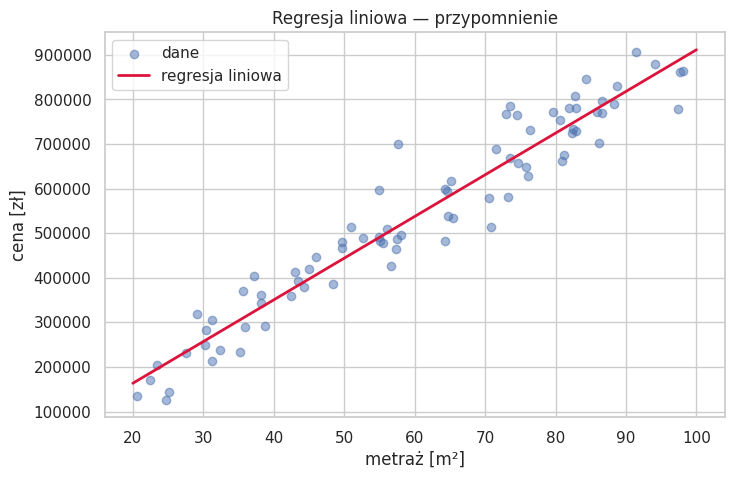

In [2]:
from sklearn.linear_model import LinearRegression

# syntetyczne dane: metraż mieszkania -> cena
rng = np.random.default_rng(RANDOM_STATE)
metraz = rng.uniform(20, 100, size=80)
cena = 5000 + 9000 * metraz + rng.normal(0, 60_000, size=80)  # zł, z szumem

X = metraz.reshape(-1, 1)   # sklearn wymaga macierzy 2D: (n_próbek, n_cech)
lin = LinearRegression().fit(X, cena)

print(f"wyuczony model: cena = {lin.intercept_:,.0f} + {lin.coef_[0]:,.0f} * metraż")
print(f"predykcja dla 65 m²: {lin.predict([[65]])[0]:,.0f} zł")

plt.scatter(metraz, cena, alpha=0.5, label="dane")
plt.plot([20, 100], lin.predict([[20], [100]]), color="crimson", lw=2, label="regresja liniowa")
plt.xlabel("metraż [m²]"); plt.ylabel("cena [zł]"); plt.legend(); plt.title("Regresja liniowa — przypomnienie")
plt.show()

### Fundamenty

**Model:** $y = w_0 + w_1x_1 + \dots + w_nx_n + \varepsilon$. Szukamy wag, które minimalizują sumę kwadratów błędów — **metoda najmniejszych kwadratów** (MNK, ang. *OLS — Ordinary Least Squares*):

$$\min_w \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**Dlaczego kwadraty?**

* Funkcja $e^2$ jest gładka i wypukła (w przeciwieństwie do $|e|$), więc minimum da się wyznaczyć analitycznie — przyrównując gradient do zera. Daje to rozwiązanie w zamkniętej postaci: $w = (X^TX)^{-1}X^Ty$.
* Mocno karzą duże błędy.

**Interpretacja:** $w_j$ to zmiana $\hat y$ przy wzroście $x_j$ o 1, **przy pozostałych cechach stałych**. Wagi można porównywać między cechami dopiero po standaryzacji.

> **Statystyka a ML.** W statystyce założenia modelu są potrzebne głównie do **wnioskowania** (p-wartości, przedziały ufności). W ML liczy się przede wszystkim **predykcja na nowych danych**, a sprawdzamy ją na zbiorze walidacyjnym, a nie testami założeń. Założeń statystycznych jest sporo, ale nie będziemy się na nich skupiać — w praktyce najważniejsze są dwa:
> * **liniowość** — jeśli zależność jest krzywa, model popełnia systematyczny błąd (bias),
> * **brak silnej współliniowości** — gdy cechy są prawie kopiami siebie, wagi stają się niestabilne i nieinterpretowalne.

### Regresja logistyczna

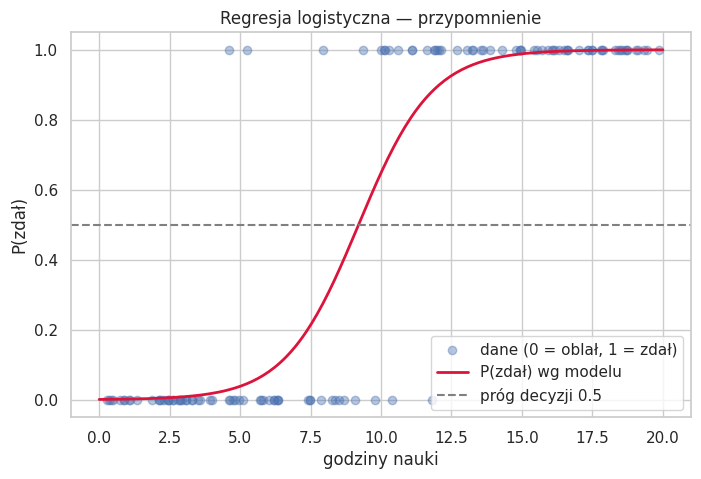

predict_proba dla 8h nauki: [0.716 0.284]  -> klasa: 0


In [3]:
from sklearn.linear_model import LogisticRegression

# syntetyczne dane: liczba godzin nauki -> zdany egzamin (0/1)
godziny = rng.uniform(0, 20, size=120)
zdal = (godziny + rng.normal(0, 3, size=120) > 10).astype(int)

log = LogisticRegression().fit(godziny.reshape(-1, 1), zdal)

siatka = np.linspace(0, 20, 200).reshape(-1, 1)
proba = log.predict_proba(siatka)[:, 1]   # kolumna 1 = P(zdał)

plt.scatter(godziny, zdal, alpha=0.4, label="dane (0 = oblał, 1 = zdał)")
plt.plot(siatka, proba, color="crimson", lw=2, label="P(zdał) wg modelu")
plt.axhline(0.5, ls="--", color="gray", label="próg decyzji 0.5")
plt.xlabel("godziny nauki"); plt.ylabel("P(zdał)"); plt.legend(); plt.title("Regresja logistyczna — przypomnienie")
plt.show()

print("predict_proba dla 8h nauki:", log.predict_proba([[8]])[0].round(3), " -> klasa:", log.predict([[8]])[0])

### Fundamenty

**Model:** logarytm szans (log-odds) jest liniowy:

$$\log\frac{p}{1-p} = w_0 + w_1x_1 + \dots = z \quad\Rightarrow\quad p = \sigma(z) = \frac{1}{1+e^{-z}}$$

**Dlaczego nie zwykła regresja liniowa na 0/1?** Zwracałaby wartości spoza $[0,1]$. Sigmoida mapuje $\mathbb{R} \to (0,1)$, więc wynik można czytać jako prawdopodobieństwo.

**Funkcja straty:** log-loss

* Jest wypukła, więc ma jedno optimum.
* Nie ma wzoru zamkniętego, dlatego solver liczy wagi iteracyjnie.

**Założenia:**

1. **Liniowość w log-odds, a nie w $p$.** Z tego wynika, że granica decyzyjna jest liniowa (hiperpłaszczyzna).
2. **Brak silnej współliniowości.** Powód ten sam co w regresji liniowej.

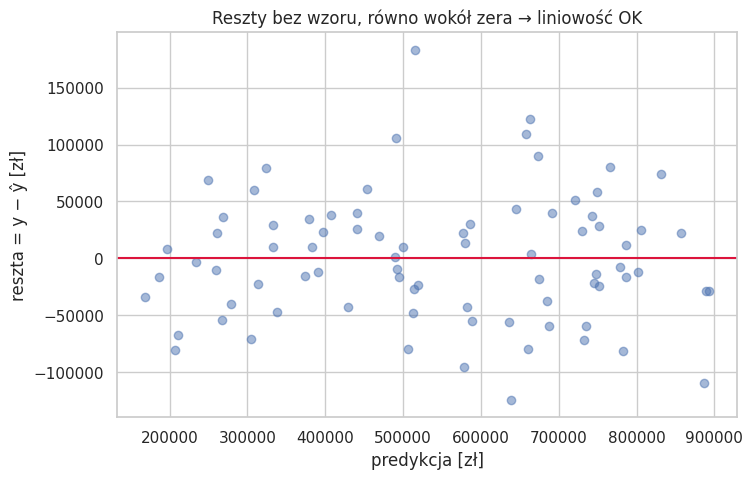

każda dodatkowa godzina nauki mnoży szanse zdania × 2.15


In [4]:
pred_lin = lin.predict(X)
reszty = cena - pred_lin
plt.scatter(pred_lin, reszty, alpha=0.5)
plt.axhline(0, color="crimson", lw=1.5)
plt.xlabel("predykcja [zł]"); plt.ylabel("reszta = y − ŷ [zł]")
plt.title("Reszty bez wzoru, równo wokół zera → liniowość OK")
plt.show()

# interpretacja regresji logistycznej: iloraz szans (odds ratio)
iloraz = np.exp(log.coef_[0][0])
print(f"każda dodatkowa godzina nauki mnoży szanse zdania × {iloraz:.2f}")

> **Uwaga: szanse to nie prawdopodobieństwo.** Mnoży się $\frac{p}{1-p}$, a nie samo $p$. Na przykładzie:
>
> * przy $p = 0.5$ szanse wynoszą 1:1; po pomnożeniu przez 2,15 mamy 2,15:1, czyli $p \approx 0.68$;
> * przy $p = 0.9$ szanse wynoszą 9:1; po pomnożeniu mamy 19,4:1, czyli $p \approx 0.95$.
>
> Iloraz szans jest stały, a przyrost prawdopodobieństwa już nie. Jest największy w okolicy $p = 0.5$ i maleje przy krańcach. Właśnie dlatego sigmoida ma kształt litery S.

**Zapamiętajcie interfejs** — każdy model w scikit-learn działa tak samo:
`model.fit(X, y)` → `model.predict(X_nowe)` (+ `predict_proba` w klasyfikacji). To za chwilę bardzo ułatwi nam życie.

---

## 3. Demo: przewidujemy ceny mieszkań w Kalifornii

**Problem (krok 1):** na podstawie danych o dzielnicy (dochody mieszkańców, wiek zabudowy, liczba pokoi...) chcemy przewidzieć **medianę wartości domu** w tej dzielnicy.
Target jest liczbą ciągłą → **regresja**.

Dane: klasyczny zbiór *California Housing* (spis powszechny USA, 1990). Jedna obserwacja = jedna dzielnica.

In [5]:
# krok 2: WCZYTANIE DANYCH
# lokalnie: plik jest w repo; w Colabie bez klonowania repo zadziała fallback z URL
try:
    df = pd.read_csv("data/california_housing.csv")
except FileNotFoundError:
    url = "https://raw.githubusercontent.com/ml-course-pg/ml-course-pg-2026/main/01-wprowadzenie/data/california_housing.csv"
    df = pd.read_csv(url)

print("wymiary:", df.shape)
df.head()

wymiary: (20433, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Znaczenie kolumn (wartości są **na dzielnicę**):

| kolumna | znaczenie |
|---|---|
| `MedInc` | mediana dochodu mieszkańców (w dziesiątkach tys. USD) |
| `HouseAge` | mediana wieku zabudowy |
| `AveRooms` / `AveBedrms` | średnia liczba pokoi / sypialni na gospodarstwo |
| `Population` | liczba mieszkańców |
| `AveOccup` | średnia liczba osób na gospodarstwo |
| `Latitude` / `Longitude` | położenie geograficzne |
| `MedHouseVal` | **TARGET**: mediana wartości domu (w setkach tys. USD) |

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20433 non-null  float64
 1   HouseAge     20433 non-null  float64
 2   AveRooms     20433 non-null  float64
 3   AveBedrms    20433 non-null  float64
 4   Population   20433 non-null  float64
 5   AveOccup     20433 non-null  float64
 6   Latitude     20433 non-null  float64
 7   Longitude    20433 non-null  float64
 8   MedHouseVal  20433 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [7]:
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20433.00,20433.00,20433.00,20433.00,20433.00,20433.00,20433.00,20433.00,20433.00
mean,3.87,28.63,5.43,1.10,1424.95,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.48,0.48,1133.21,10.44,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.54,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1722.00,3.28,37.72,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


### Krok 3: EDA — szukamy problemów, nie ładnych wykresów

Zacznijmy od najważniejszej zmiennej: **targetu**.

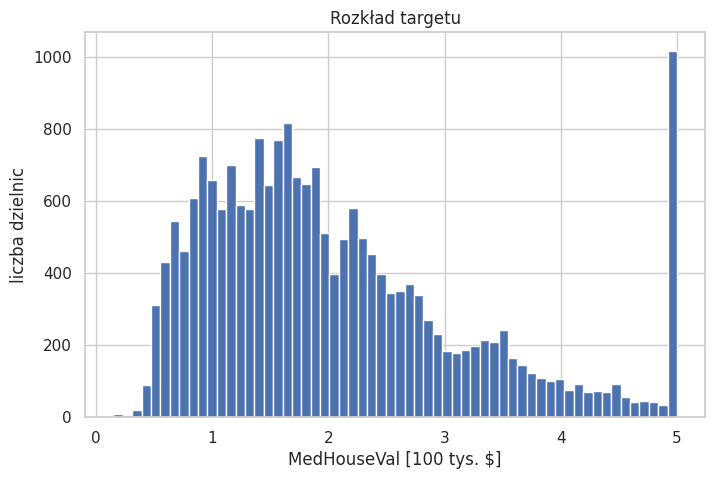

In [8]:
df["MedHouseVal"].hist(bins=60)
plt.xlabel("MedHouseVal [100 tys. $]"); plt.ylabel("liczba dzielnic")
plt.title("Rozkład targetu")
plt.show()

❓ **Co jest nie tak z tym rozkładem?**

Ten "słupek" przy 5.0 to nie przypadek — wartości powyżej 500 tys. USD zostały przy zbieraniu danych **obcięte** (ang. *capping*).
Model nigdy nie nauczy się przewidywać cen droższych dzielnic, bo w danych ich... nie ma.

In [9]:
ile_cap = (df["MedHouseVal"] >= 5).sum()
print(f"dzielnic z obciętym targetem: {ile_cap} ({ile_cap/len(df):.1%})")

dzielnic z obciętym targetem: 985 (4.8%)


Druga rzecz widoczna na histogramie: rozkład jest **prawostronnie skośny** — dużo tanich dzielnic, długi ogon drogich. Typowe dla cen, dochodów, wszystkiego "pieniężnego".

Klasyczna strategia przetwarzania takiej zmiennej to **transformacja logarytmiczna**: ściąga ogon, upodabnia rozkład do normalnego

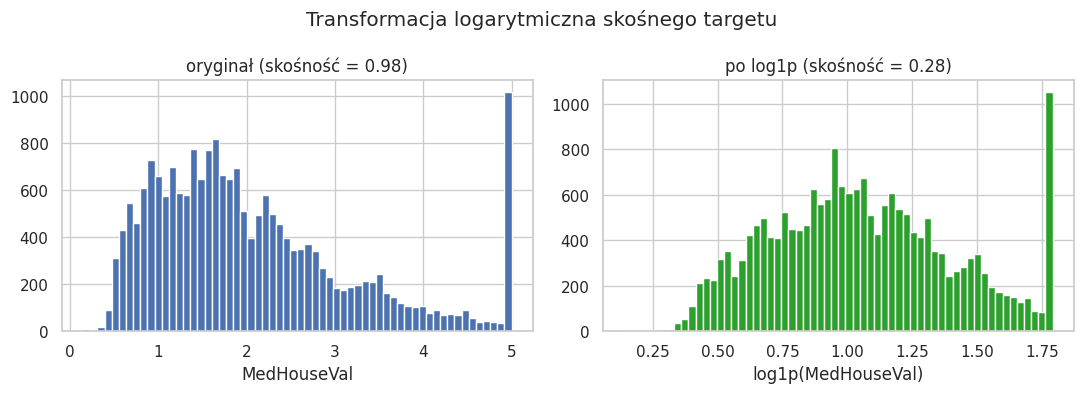

In [10]:
skosnosc = df["MedHouseVal"].skew()
skosnosc_log = np.log1p(df["MedHouseVal"]).skew()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(df["MedHouseVal"], bins=60)
ax[0].set_title(f"oryginał (skośność = {skosnosc:.2f})"); ax[0].set_xlabel("MedHouseVal")
ax[1].hist(np.log1p(df["MedHouseVal"]), bins=60, color="tab:green")
ax[1].set_title(f"po log1p (skośność = {skosnosc_log:.2f})"); ax[1].set_xlabel("log1p(MedHouseVal)")
plt.suptitle("Transformacja logarytmiczna skośnego targetu")
plt.tight_layout(); plt.show()

Jak tego używać w praktyce: trenujemy model na `np.log1p(y)`, a predykcje odwracamy przez `np.expm1(ŷ)` — inaczej metryki wyjdą "w logarytmach" i stracą interpretację.

* `np.log1p(y)` liczy $\ln(1 + y)$;
* `np.expm1(ŷ)` liczy $e^{\hat{y}} - 1$ (nazwa od *exp minus 1*).

**Dlaczego `log1p` zamiast zwykłego `log`?**

* **Radzi sobie z zerem.** $\ln(0) = -\infty$, a $\ln(1+0) = 0$. Przy targetach, które mogą wynosić 0 (liczba rezerwacji, sprzedaż), zwykły log się wysypie.
* **Jest dokładniejszy dla małych wartości.** Dla bardzo małych $y$ wynik `np.log(1 + y)` traci precyzję przez zaokrąglenia, a `log1p` liczy to dokładnie.

**Dziś zostajemy przy oryginalnym targecie** — skośność jest tu umiarkowana, a chcemy czytać błędy wprost w dolarach dla ułatwienia.

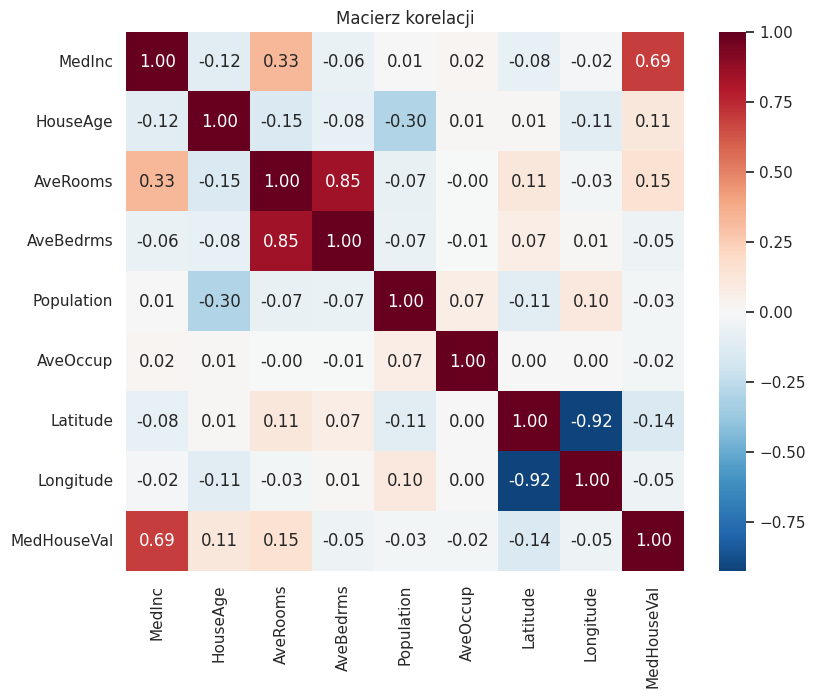

In [11]:
# korelacje cech z targetem i między sobą
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Macierz korelacji")
plt.show()

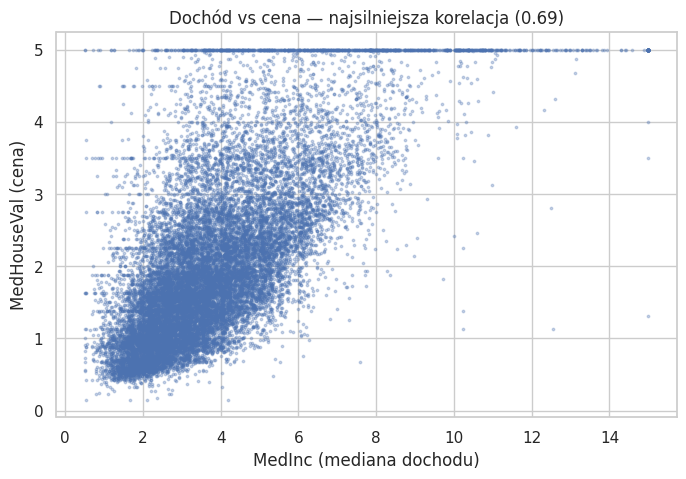

In [12]:
# najsilniejsza zależność: dochód vs cena
plt.scatter(df["MedInc"], df["MedHouseVal"], s=3, alpha=0.3)
plt.xlabel("MedInc (mediana dochodu)"); plt.ylabel("MedHouseVal (cena)")
plt.title("Dochód vs cena — najsilniejsza korelacja (0.69)")
plt.show()

### Krok 4: Tworzenie nowych cech (feature engineering)

W tym zbiorze wszystkie cechy są **numeryczne** (zmienne kategoryczne spotkacie w zadaniu grupowym!).
Ale możemy tworzyć **nowe cechy** z istniejących — to często daje więcej niż lepszy model.
Skąd wiedzieć, jakie cechy tworzyć?

In [13]:
df["BedrmsShare"] = df["AveBedrms"] / df["AveRooms"]     # udział sypialni w pokojach

nowe = df[["BedrmsShare", "MedHouseVal"]].corr().iloc[0, 1]
stare = df[["AveBedrms", "MedHouseVal"]].corr().iloc[0, 1]
print(f"korelacja z targetem:  AveBedrms = {stare:+.3f}   ->   BedrmsShare = {nowe:+.3f}")

korelacja z targetem:  AveBedrms = -0.047   ->   BedrmsShare = -0.256


Sama `AveBedrms` miała korelację ~0, ale jej **stosunek** do liczby pokoi niesie wyraźny sygnał. Ten sam surowy pomiar — inna reprezentacja — inna wartość dla modelu.

### Krok 5: Podział danych — train / walidacja / test

**Najważniejsza zasada dzisiejszych zajęć:** model oceniamy wyłącznie na danych, **których nie widział podczas treningu**.

* **train (60%)** — na tym model się uczy
* **walidacja (20%)** — na tym porównujemy warianty i podejmujemy decyzje
* **test (20%)** — używamy **RAZ**, na samym końcu, do uczciwej oceny finalnego modelu

Po co osobna walidacja i test?

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]

# dzielimy dwukrotnie: najpierw odcinamy test, potem z reszty wydzielamy walidację
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE)

print(f"train: {X_train.shape[0]:>6} wierszy (60%)")
print(f"val:   {X_val.shape[0]:>6} wierszy (20%)")
print(f"test:  {X_test.shape[0]:>6} wierszy (20%)")

train:  12259 wierszy (60%)
val:     4087 wierszy (20%)
test:    4087 wierszy (20%)


### ⚠️ Data leakage — najczęstszy błąd w projektach ML

Wiele modeli wymaga **skalowania cech** (np. do średniej 0 i odchylenia 1). Pytanie: na czym policzyć średnią i odchylenie? A czy B?

```python
#A
scaler.fit(X)
X_train_s = scaler.transform(X_train)

#B
scaler.fit(X_train)
X_val_s = scaler.transform(X_val)
```

### Krok 6: Baseline

Zanim wytrenujemy cokolwiek sensownego: jaki wynik osiąga model, który **zawsze przewiduje średnią**?
Bez tego punktu odniesienia każdy wynik jest liczbą bez kontekstu.

In [15]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

def ocena(model, nazwa):
    """trenuje na train, ocenia na train i walidacji"""
    model.fit(X_train, y_train)
    pred_val = model.predict(X_val)
    rmse_tr = root_mean_squared_error(y_train, model.predict(X_train))
    rmse_val = root_mean_squared_error(y_val, pred_val)
    mae_val = mean_absolute_error(y_val, pred_val)
    print(f"{nazwa:<35} RMSE train: {rmse_tr:.3f}   RMSE val: {rmse_val:.3f}   MAE val: {mae_val:.3f}")
    return rmse_val

baseline = ocena(DummyRegressor(strategy="mean"), "DummyRegressor (zawsze średnia)")

DummyRegressor (zawsze średnia)     RMSE train: 1.152   RMSE val: 1.147   MAE val: 0.905


RMSE (pierwiastek błędu średniokwadratowego) i MAE (średni błąd bezwzględny) są **w jednostkach targetu**: baseline myli się o **~115 tys. USD**. Każdy nasz model musi być od tego lepszy — inaczej jest bezwartościowy.

Czemu dwie metryki? Bo patrzą na co innego: **RMSE** mocniej karze duże pomyłki (czyli "ogon" — drogie dzielnice), **MAE** opisuje przeciętny przypadek. Gdy RMSE ≫ MAE, model ma pojedyncze duże wpadki.

### Krok 7: Model liniowy + Pipeline

In [16]:
ocena(LinearRegression(), "LinearRegression (bez skalowania)");

LinearRegression (bez skalowania)   RMSE train: 0.716   RMSE val: 0.707   MAE val: 0.519


Działa — błąd spadł z ~115 do ~72 tys. USD. Ale zaraz zaczniemy skalować i transformować cechy, a wtedy grozi nam leakage z poprzedniej sekcji.
Rozwiązanie: **Pipeline** — sklejamy preprocessing i model w jeden obiekt.

**Pipeline gwarantuje, że:**
1. `fit()` uczy skaler tylko na danych treningowych — leakage jest niemożliwy,
2. cały przepis "surowe dane → predykcja" to **jeden obiekt**, który można zapisać i przekazać dalej.

In [17]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pipe_lin = make_pipeline(StandardScaler(), LinearRegression())
pipe_lin

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])

In [18]:
ocena(pipe_lin, "Pipeline: skaler + LinearRegression");

Pipeline: skaler + LinearRegression RMSE train: 0.716   RMSE val: 0.707   MAE val: 0.519


Wynik identyczny, ale od teraz **każdy** nasz model będzie pipeline'em — przyzwyczajajcie się, to standard w praktyce.

---

## 4. Generalizacja i kompromis bias–variance

Dlaczego w ogóle dzielimy dane? Bo interesuje nas **generalizacja** — jakość na danych, których model nie widział.

Zbadajmy to w **kontrolowanym eksperymencie**: wygenerujemy dane, których prawdziwy kształt znamy (sinusoida + szum), i będziemy zwiększać złożoność modelu przez **cechy wielomianowe** (x, x², x³, ...).

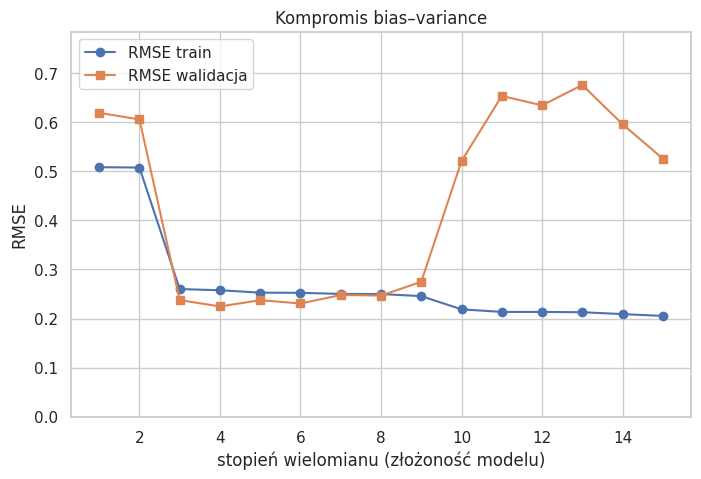

najlepszy stopień wg walidacji: 4


In [19]:
from sklearn.preprocessing import PolynomialFeatures

# dane syntetyczne: znamy prawdę (sinus), więc widzimy, kiedy model błądzi
rng2 = np.random.default_rng(0)
Xs = np.sort(rng2.uniform(0, 6, size=60)).reshape(-1, 1)
ys = np.sin(Xs).ravel() + rng2.normal(0, 0.25, size=60)
Xs_tr, Xs_val, ys_tr, ys_val = train_test_split(Xs, ys, test_size=0.35, random_state=RANDOM_STATE)

stopnie = list(range(1, 16))
rmse_tr, rmse_val = [], []
for d in stopnie:
    p = make_pipeline(PolynomialFeatures(degree=d), StandardScaler(), LinearRegression())
    p.fit(Xs_tr, ys_tr)
    rmse_tr.append(root_mean_squared_error(ys_tr, p.predict(Xs_tr)))
    rmse_val.append(root_mean_squared_error(ys_val, p.predict(Xs_val)))

plt.plot(stopnie, rmse_tr, "o-", label="RMSE train")
plt.plot(stopnie, rmse_val, "s-", label="RMSE walidacja")
plt.ylim(0, max(rmse_val[:12]) * 1.2)
plt.xlabel("stopień wielomianu (złożoność modelu)"); plt.ylabel("RMSE")
plt.title("Kompromis bias–variance")
plt.legend(); plt.show()

print(f"najlepszy stopień wg walidacji: {stopnie[int(np.argmin(rmse_val))]}")

Klasyczny obrazek — **litera U** na krzywej walidacyjnej:

* **po lewej (niski stopień): duży bias** — model za prosty, nie łapie zależności. Błąd wysoki na train I na walidacji. To **niedouczenie** (underfitting).
* **po prawej (wysoki stopień): duża wariancja** — model uczy się szumu z train. Błąd na train spada, na walidacji **rośnie**. To **przeuczenie** (overfitting).
* **środek** — złoty punkt: model wystarczająco elastyczny, ale jeszcze nie zapamiętuje szumu.

**Rozjazd między train a walidacją to termometr przeuczenia.** Zobaczmy, JAK wyglądają te modele na tle prawdy (szara linia):

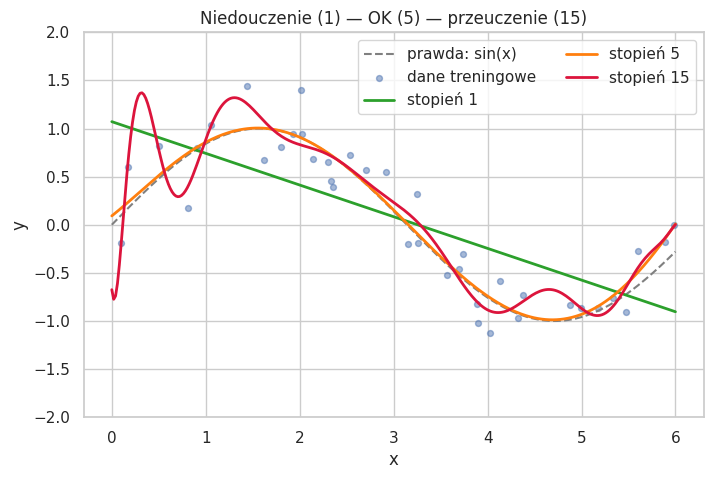

In [28]:
siatka_s = np.linspace(0, 6, 300).reshape(-1, 1)
plt.plot(siatka_s, np.sin(siatka_s), color="gray", lw=1.5, ls="--", label="prawda: sin(x)")
plt.scatter(Xs_tr, ys_tr, s=18, alpha=0.5, label="dane treningowe")
for d, kolor in [(1, "tab:green"), (5, "tab:orange"), (15, "crimson")]:
    p = make_pipeline(PolynomialFeatures(degree=d), StandardScaler(), LinearRegression())
    p.fit(Xs_tr, ys_tr)
    plt.plot(siatka_s, p.predict(siatka_s), color=kolor, lw=2, label=f"stopień {d}")
plt.ylim(-2, 2); plt.xlabel("x"); plt.ylabel("y")
plt.title("Niedouczenie (1) — OK (5) — przeuczenie (15)")
plt.legend(ncol=2); plt.show()

## 5. Krok w stronę GAM: splajny zamiast wielomianów

Wielomian stopnia 15 ma jeszcze jedną paskudną wadę: **szaleje na brzegach** danych. Wielomian jest **globalny** — dopasowanie w jednym miejscu wygina krzywą wszędzie indziej.

Eleganckie rozwiązanie: **splajny** (`SplineTransformer`) — sklejane, lokalne kawałki wielomianów niskiego stopnia.
Nieliniowość modelujemy **lokalnie**, a model pozostaje liniowy względem nowych cech.

**Wróćmy do prawdziwych danych** — mała próbka dzielnic, jedna cecha (`MedInc`):

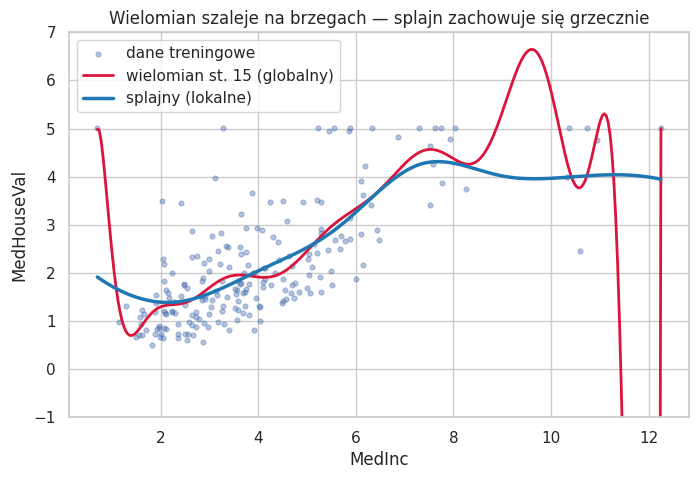

In [29]:
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import Ridge

# mała próbka prawdziwych danych: dochód -> cena
maly = df.sample(300, random_state=RANDOM_STATE)
Xm = maly[["MedInc"]].values
ym = maly["MedHouseVal"].values
Xm_tr, Xm_val, ym_tr, ym_val = train_test_split(Xm, ym, test_size=0.3, random_state=RANDOM_STATE)
siatka = np.linspace(Xm.min(), Xm.max(), 300).reshape(-1, 1)

p_poly = make_pipeline(PolynomialFeatures(degree=15), StandardScaler(), LinearRegression()).fit(Xm_tr, ym_tr)
p_spl  = make_pipeline(SplineTransformer(n_knots=8, degree=3), Ridge(alpha=1.0)).fit(Xm_tr, ym_tr)

plt.scatter(Xm_tr, ym_tr, s=12, alpha=0.4, label="dane treningowe")
plt.plot(siatka, p_poly.predict(siatka), color="crimson", lw=2, label="wielomian st. 15 (globalny)")
plt.plot(siatka, p_spl.predict(siatka), color="tab:blue", lw=2.5, label="splajny (lokalne)")
plt.ylim(-1, 7); plt.xlabel("MedInc"); plt.ylabel("MedHouseVal")
plt.title("Wielomian szaleje na brzegach — splajn zachowuje się grzecznie")
plt.legend(); plt.show()

> 💡 **To jest idea modeli GAM** (*Generalized Additive Models*): każda cecha dostaje własną gładką, nieliniową transformację, a wynik jest ich **sumą** — więc model łapie nieliniowości, ale nadal widać wkład każdej cechy z osobna (interpretowalność!).
> W scikit-learn składamy to sami: `SplineTransformer` + model liniowy.

Zastosujmy to do **pełnego zbioru, wszystkich cech**:

In [30]:
pipe_gam = make_pipeline(StandardScaler(), SplineTransformer(n_knots=8, degree=3), Ridge(alpha=1.0))
ocena(pipe_gam, "GAM: splajny + Ridge");

GAM: splajny + Ridge                RMSE train: 0.650   RMSE val: 0.651   MAE val: 0.468


Błąd spadł z ~0.71 do ~0.65 (czyli o ~6 tys. USD na dzielnicę) — **bez zmiany modelu na "potężniejszy"**, tylko przez mądrzejszą reprezentację cech. W następnych blokach porównamy takie podejścia z modelami nieliniowymi z natury.

---

## 6. Regularyzacja — kaganiec na przeuczenie

Widzieliśmy: im więcej cech (wielomiany, splajny), tym większe ryzyko przeuczenia. Zamiast ręcznie ograniczać liczbę cech, możemy **karać model za duże współczynniki** — to jest regularyzacja:

$$\text{koszt} = \underbrace{\text{błąd dopasowania}}_{\text{jak dotąd}} + \alpha \cdot \underbrace{\text{kara za duże wagi}}_{\text{nowość}}$$

| model | kara | efekt |
|---|---|---|
| **Ridge** (L2) | suma kwadratów wag | wagi **kurczą się** do zera, ale go nie osiągają |
| **Lasso** (L1) | suma wartości bezwzględnych | wagi **dokładnie zerują się** → automatyczna selekcja cech |
| **ElasticNet** | mieszanka L1 + L2 | kompromis; dobry przy wielu skorelowanych cechach |

Parametr **α** steruje siłą kary: α=0 → zwykła regresja; α→∞ → wszystkie wagi do zera (model = średnia).

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.427e+02, tolerance: 1.626e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.913e+02, tolerance: 1.626e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.816e+00, tolerance: 1.626e

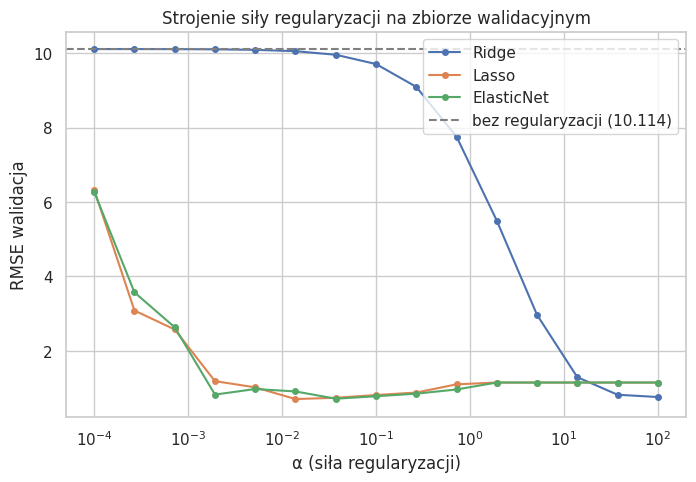

bez regularyzacji  RMSE val: 10.114
Ridge              najlepsze RMSE val: 0.757  przy α = 100.0000
Lasso              najlepsze RMSE val: 0.703  przy α = 0.0139
ElasticNet         najlepsze RMSE val: 0.712  przy α = 0.0373


In [31]:
from sklearn.linear_model import Lasso, ElasticNet

# dużo cech: wielomiany stopnia 2 na wszystkich 9 cechach -> ryzyko przeuczenia
przygotowanie = make_pipeline(StandardScaler(), PolynomialFeatures(degree=2, include_bias=False), StandardScaler())

# punkt odniesienia: ten sam zestaw cech BEZ regularyzacji
bez_reg = make_pipeline(przygotowanie, LinearRegression()).fit(X_train, y_train)
rmse_bez_reg = root_mean_squared_error(y_val, bez_reg.predict(X_val))

alfy = np.logspace(-4, 2, 15)
wyniki = {"Ridge": [], "Lasso": [], "ElasticNet": []}
for a in alfy:
    for nazwa, Model in [("Ridge", Ridge), ("Lasso", Lasso), ("ElasticNet", ElasticNet)]:
        m = make_pipeline(przygotowanie, Model(alpha=a, max_iter=5000))
        m.fit(X_train, y_train)
        wyniki[nazwa].append(root_mean_squared_error(y_val, m.predict(X_val)))

for nazwa, w in wyniki.items():
    plt.plot(alfy, w, "o-", label=nazwa, ms=4)
plt.axhline(rmse_bez_reg, ls="--", color="gray", label=f"bez regularyzacji ({rmse_bez_reg:.3f})")
plt.xscale("log"); plt.xlabel("α (siła regularyzacji)"); plt.ylabel("RMSE walidacja")
plt.title("Strojenie siły regularyzacji na zbiorze walidacyjnym")
plt.legend(); plt.show()

print(f"{'bez regularyzacji':<18} RMSE val: {rmse_bez_reg:.3f}")
for nazwa, w in wyniki.items():
    print(f"{nazwa:<18} najlepsze RMSE val: {min(w):.3f}  przy α = {alfy[np.argmin(w)]:.4f}")

Zwróćcie uwagę na trzy rzeczy:

1. **Bez regularyzacji ten model jest katastrofą** (RMSE ≈ 10, czyli ~9× gorzej niż baseline!). 54 skorelowane cechy + outliery w danych = niestabilna, skrajnie przeuczona regresja. Wystarczy odrobina kary, by model wrócił do rozsądku.
2. **Za duże α też szkodzi** — kara dusi wszystkie wagi do zera i model zmierza do przewidywania średniej. Regularyzacja to pokrętło, które trzeba **nastroić**.
3. Po to właśnie mamy zbiór walidacyjny: **α wybieramy patrząc na walidację** — nigdy na test.

Zobaczmy jeszcze charakterystyczną różnicę Ridge vs Lasso — **co robią ze współczynnikami**:

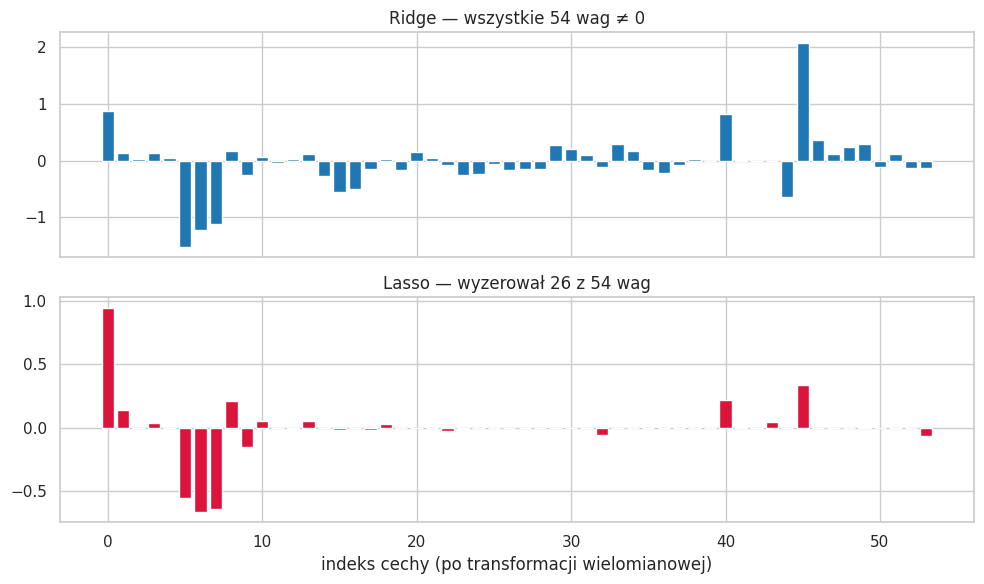

In [24]:
ridge_m = make_pipeline(przygotowanie, Ridge(alpha=1.0)).fit(X_train, y_train)
lasso_m = make_pipeline(przygotowanie, Lasso(alpha=0.01, max_iter=5000)).fit(X_train, y_train)

wr = ridge_m[-1].coef_
wl = lasso_m[-1].coef_
x = np.arange(len(wr))
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].bar(x, wr, color="tab:blue");  ax[0].set_title(f"Ridge — wszystkie {len(wr)} wag ≠ 0")
ax[1].bar(x, wl, color="crimson");   ax[1].set_title(f"Lasso — wyzerował {np.sum(wl == 0)} z {len(wl)} wag")
ax[1].set_xlabel("indeks cechy (po transformacji wielomianowej)")
plt.tight_layout(); plt.show()

Lasso **samo wybrało cechy**, zerując większość wag.

---

## 7. Finał: ocena na teście, zapis i ponowne użycie modelu

Iterowaliśmy na walidacji — czas na finał. Wybieramy najlepszy wariant (splajny + Ridge), trenujemy go na **train + walidacja**, dlaczego?

In [33]:
model_finalny = make_pipeline(StandardScaler(), SplineTransformer(n_knots=8, degree=3), Ridge(alpha=1.0))
model_finalny.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]))

rmse_test = root_mean_squared_error(y_test, model_finalny.predict(X_test))
r2_test = r2_score(y_test, model_finalny.predict(X_test))
print(f"WYNIK KOŃCOWY (test, użyty 1 raz):  RMSE = {rmse_test:.3f}")
print(f"vs baseline (zawsze średnia):       RMSE = {baseline:.3f}")

WYNIK KOŃCOWY (test, użyty 1 raz):  RMSE = 0.685
vs baseline (zawsze średnia):       RMSE = 1.147


Wynik na teście jest zbliżony do walidacyjnego → model **generalizuje**; nie "przeuczyliśmy się" do walidacji.

Ostatni krok workflow: **zapis modelu**. Wytrenowany pipeline to obiekt Pythona — zapisujemy go w całości (preprocessing + model!) biblioteką `joblib`.

In [26]:
import joblib

joblib.dump(model_finalny, "model_california.joblib")
print("zapisano: model_california.joblib")

zapisano: model_california.joblib


In [27]:
# ...tydzień później, w innym skrypcie / na serwerze produkcyjnym:
model_wczytany = joblib.load("model_california.joblib")

nowa_dzielnica = pd.DataFrame([{
    "MedInc": 5.2, "HouseAge": 25.0, "AveRooms": 5.5, "AveBedrms": 1.1,
    "Population": 1200.0, "AveOccup": 2.8, "Latitude": 34.2, "Longitude": -118.4,
    "BedrmsShare": 1.1 / 5.5,
}])
cena = model_wczytany.predict(nowa_dzielnica)[0]
print(f"przewidywana mediana wartości domu: {cena * 100_000:,.0f} $")

przewidywana mediana wartości domu: 283,821 $


Zauważcie: wczytany pipeline przyjmuje **surowe dane** i sam wykonuje całe przetwarzanie

---

## 8. Podsumowanie — i co dalej

Przeszliśmy dziś cały workflow: dane → EDA → cechy → podział → baseline → pipeline → bias-variance → splajny (GAM) → regularyzacja (Ridge/Lasso/ElasticNet) → test → zapis.

### Rachunek sumienia — co dziś zrobiliśmy "naiwnie"?

| co zrobiliśmy dziś | dlaczego to naiwne | kiedy naprawimy |
|---|---|---|
| outliery w `AveOccup` tylko odnotowaliśmy | psują skalowanie i model | **Blok 2** |
| braki danych — nie było ich w demo (będą w zadaniu!) | prawdziwe dane zawsze mają braki | **Blok 2** |
| pojedynczy podział train/val | wynik zależy od łutu szczęścia w losowaniu | **Blok 2**: walidacja krzyżowa |
| tylko RMSE i MAE | jedna metryka potrafi kłamać | **Blok 2**: metryki |
| cechy wybrało za nas Lasso | to tylko jedna z wielu technik | **Blok 2**: selekcja cech |

### Teraz: zadanie grupowe 🏨

Otwórzcie notebook `02_zadanie_grupowe_hotele.ipynb`. Ten sam workflow, ale:
* dane **brudne** (braki, tekst, outliery),
* zadanie **klasyfikacyjne** — a wybór modelu należy do was